<a href="https://colab.research.google.com/github/firatsayici/derinogrenme/blob/main/MobileNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Google Drive Bağlantısı
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Veri Seti Yükleme ve Hazırlama

In [2]:
dataset_path = "/content/drive/MyDrive/data" # Kendi dizininize göre teyit ediniz.

filepaths = []
labels = []

if not os.path.exists(dataset_path):
    print(f"Hata: Belirtilen dizin bulunamadı: {dataset_path}")
else:
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            for file in os.listdir(category_path):
                filepaths.append(os.path.join(category_path, file))
                labels.append(category)

    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    print(f"Toplam {len(df)} dosya yüklendi.")

Toplam 7553 dosya yüklendi.


3. Veri Setinin Bölünmesi (%80 Eğitim-Validasyon / %20 Test)

In [3]:
train_val_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
train_df, val_df = train_test_split(train_val_df, test_size=0.20, random_state=42, stratify=train_val_df['label'])

4. Veri Artırımı (Data Augmentation) ve Generator

In [4]:
image_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=image_size, batch_size=batch_size, class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=image_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=image_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

Found 4833 validated image filenames belonging to 2 classes.
Found 1209 validated image filenames belonging to 2 classes.
Found 1511 validated image filenames belonging to 2 classes.


5. MobileNet Modeli ve Transfer Learning (Öğrenme Transferi)

In [5]:
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))

# DİKKAT: Eğitim süresini dramatik şekilde kısaltan kritik kod (Ağırlıkları dondurma)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


6. Modelin Derlenmesi

In [6]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


7. Callbacks

In [7]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)

8. Modelin Eğitilmesi

In [8]:
print("Eğitim Başlıyor...")
epochs = 100
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr]
)

Eğitim Başlıyor...
Epoch 1/100
  4/152 ━━━━━━━━━━━━━━━━━━━━ 18:44 8s/step - accuracy: 0.5150 - loss: 1.1114

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 2411s 15s/step - accuracy: 0.9576 - loss: 0.1133 - val_accuracy: 0.9942 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 81s 532ms/step - accuracy: 0.9843 - loss: 0.0467 - val_accuracy: 0.9917 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 80s 527ms/step - accuracy: 0.9830 - loss: 0.0469 - val_accuracy: 0.9926 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 81s 533ms/step - accuracy: 0.9853 - loss: 0.0421 - val_accuracy: 0.9934 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 83s 547ms/step - accuracy: 0.9872 - loss: 0.0385 - val_accuracy: 0.9942 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 141s 543ms/step - accuracy: 0.9872 - loss: 0.0344 - val_accuracy: 0.9934 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 143s 548ms/step - accuracy: 0.9886

9. Eğitim ve Validasyon Grafikleri

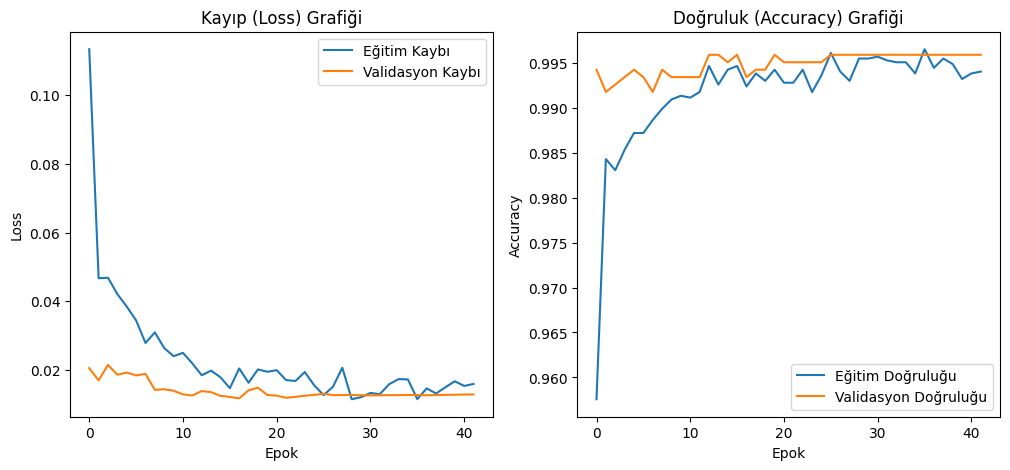

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Validasyon Kaybı')
plt.title('Kayıp (Loss) Grafiği')
plt.xlabel('Epok')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Validasyon Doğruluğu')
plt.title('Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epok')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

10. Test Verisi İle Tahmin ve Metrikler

Test Seti Üzerinde Değerlendirme Yapılıyor...
48/48 ━━━━━━━━━━━━━━━━━━━━ 586s 12s/step

--- PERFORMANS METRİKLERİ ---
Accuracy (Doğruluk): 0.9967
Precision (Duyarlılık): 0.9974
Recall (Hassasiyet): 0.9961
Specificity (Özgüllük): 0.9973
F1-Score: 0.9967


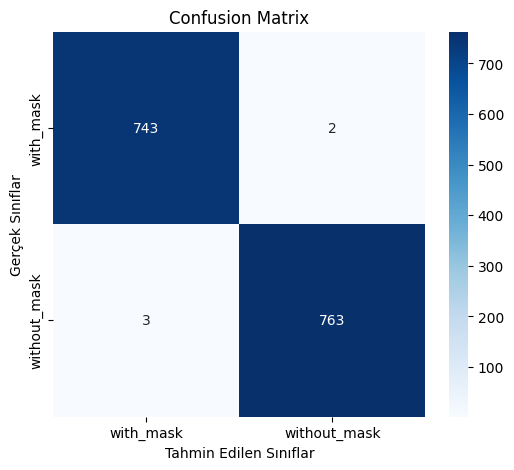

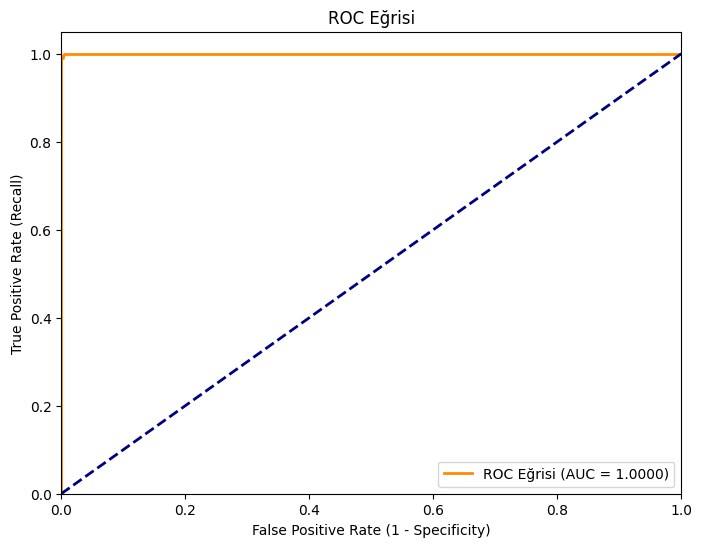

In [10]:
print("Test Seti Üzerinde Değerlendirme Yapılıyor...")
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

conf_matrix = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

tn, fp, fn, tp = conf_matrix.ravel()
specificity = tn / (tn + fp)

print("\n--- PERFORMANS METRİKLERİ ---")
print(f"Accuracy (Doğruluk): {accuracy:.4f}")
print(f"Precision (Duyarlılık): {precision:.4f}")
print(f"Recall (Hassasiyet): {recall:.4f}")
print(f"Specificity (Özgüllük): {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix Görseli
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Sınıflar')
plt.xlabel('Tahmin Edilen Sınıflar')
plt.show()

# ROC Eğrisi ve AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Eğrisi')
plt.legend(loc="lower right")
plt.show()